# Forbedrede modeller: spilletid, form og ensemble

Vi sammenligner åtte forhåndsdefinerte varianter på 2023–24 og 2024–25. Hver fold trener bare på tidligere sesonger fra 2022–23. Vinneren velges etter gjennomsnittlig sesong-RMSE, og testes deretter på 2025–26. Den sesongen er tidligere undersøkt og ikke en urørt test.

Modellene inkluderer referansene Ridge/HGB, HGB med historiske trender og to størrelser, en spilletidsmodell og tre enkle gjennomsnittsensembler. Ingen garantert forbedring: referansemodellene kan vinne.

**Før kamp, ikke før deadline:** offisielle historiske deadline-snapshots er ikke tilgjengelige her. Doble gameweeks kan inneholde informasjon fra tidligere kamper i runden. Resultatene er ikke en deadline-backtest. Tidligere notebooks beholdes.

Aktiver prosjektets `.venv`, kjør alle celler. Artefakter lagres i en ny mappe.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/improved_models.py').exists())
sys.path.insert(0, str(ROOT / 'src'))
from model_experiments import load_data, grouped_metrics, ranking
from improved_models import *
data, metadata = load_data(ROOT)
data = enrich(data)
display(pd.DataFrame(CONFIGS, index=['kind', 'leaves', 'extended']).T)
print('Ensembler:', BLENDS)

,kind,leaves,extended
ridge_reference,ridge,7,False
hgb_reference,hgb,7,False
hgb_extended7,hgb,7,True
hgb_extended15,hgb,15,True
minutes_mixture,mixture,7,True


Ensembler: {'blend_ridge_hgb': ['ridge_reference', 'hgb_extended7'], 'blend_direct_minutes': ['hgb_extended7', 'minutes_mixture'], 'blend_three': ['ridge_reference', 'hgb_extended7', 'minutes_mixture']}


## To tidsfold og kandidatspillere

`candidate_RMSE` bruker spillere med minst 60 minutter i historisk femkampersgjennomsnitt. Utvalget bestemmes før kampen. Alle spillere inkluderes fortsatt i hovedmetrikken og treningen. Nye features er differanser, rater og kombinasjoner av eksisterende historiske input.

Spilletidsmodellen lærer tre sannsynligheter og separate poengmodeller. Faktiske minutter brukes kun som treningsetikett og ved etteranalyse, aldri som prediksjonsinput.

Completed validation: 2023-24


Completed validation: 2024-25


,model,season,n,candidate_RMSE,MAE,RMSE,Spearman,bias,actual_mean,predicted_mean
0,ridge_reference,2023-24,29725,3.1170,0.9981,1.9200,0.6766,-0.0115,1.0520,1.0405
1,hgb_reference,2023-24,29725,3.1287,0.9724,1.9209,0.6826,0.0411,1.0520,1.0931
2,hgb_extended7,2023-24,29725,3.1305,0.9709,1.9210,0.6836,0.0396,1.0520,1.0916
3,hgb_extended15,2023-24,29725,3.1640,0.9789,1.9345,0.6834,0.0517,1.0520,1.1037
4,minutes_mixture,2023-24,29725,3.1260,0.9620,1.9187,0.6886,0.0299,1.0520,1.0819
5,blend_ridge_hgb,2023-24,29725,3.1140,0.9755,1.9140,0.6826,0.0140,1.0520,1.0661
6,blend_direct_minutes,2023-24,29725,3.1238,0.9652,1.9171,0.6883,0.0347,1.0520,1.0868
7,blend_three,2023-24,29725,3.1135,0.9665,1.9127,0.6856,0.0193,1.0520,1.0713
8,ridge_reference,2024-25,27283,3.0562,1.0329,1.9287,0.6930,-0.0214,1.1469,1.1255
9,hgb_reference,2024-25,27283,3.0658,1.0079,1.9282,0.6996,0.0062,1.1469,1.1531


,RMSE,MAE,Spearman,candidate_RMSE
model,,,,
blend_three,1.9171,0.9869,0.6938,3.0833
blend_ridge_hgb,1.9186,0.9943,0.6908,3.0836
blend_direct_minutes,1.9210,0.9857,0.6963,3.0930
minutes_mixture,1.9217,0.9832,0.6972,3.0945
ridge_reference,1.9244,1.0155,0.6848,3.0866
hgb_reference,1.9246,0.9902,0.6911,3.0973
hgb_extended7,1.9249,0.9904,0.6918,3.0991
hgb_extended15,1.9320,0.9938,0.6922,3.1175


,season,log_loss,brier_60plus
0,2023-24,0.4712,0.0817
1,2024-25,0.5095,0.0913


Valgt på validering: blend_three


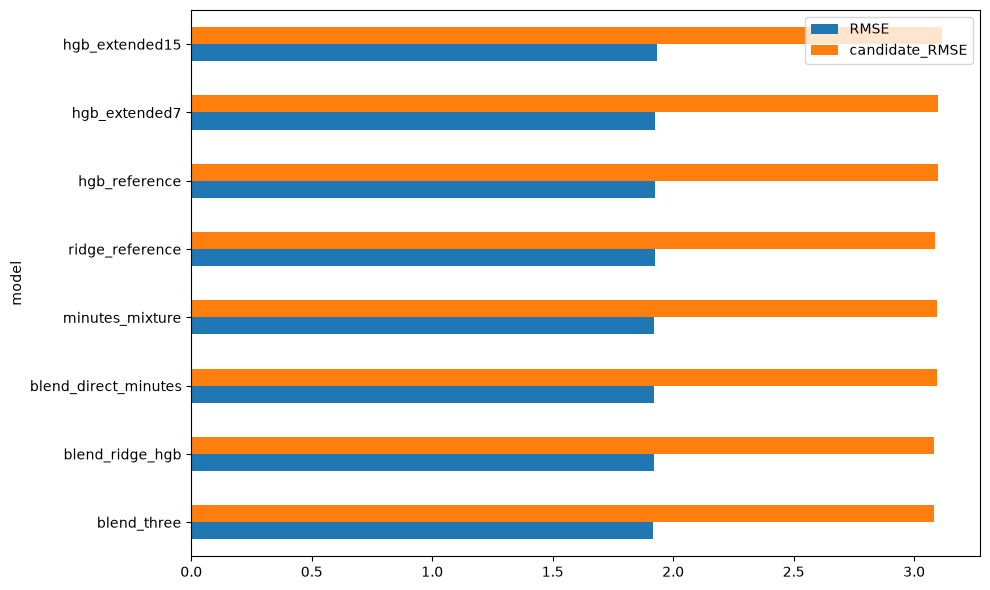

In [2]:
folds, summary, oof, minutes_scores = compare(data)
display(folds.round(4))
display(summary.round(4))
display(minutes_scores.round(4))
winner = summary.index[0]
print('Valgt på validering:', winner)
summary[['RMSE', 'candidate_RMSE']].plot.barh(figsize=(10, 6))
plt.tight_layout()

## Usikkerhet mot HGB-referansen

Positiv MSE-gevinst betyr forbedring. Vi trekker hele gameweeks samlet for å ta hensyn til noe av avhengigheten mellom spillerne. Intervallet er beskrivende: det korrigerer ikke for modellvalg og gir ingen garanti om fremtidig gevinst.

In [3]:
display(pd.DataFrame([{'model': name, **bootstrap_gain(oof, name)}
                      for name in summary.index]).round(5))

,model,MSE_gain,low_95,high_95
0,blend_three,0.02857,0.01836,0.03917
1,blend_ridge_hgb,0.02301,0.01092,0.03562
2,blend_direct_minutes,0.01376,0.00322,0.02369
3,minutes_mixture,0.01071,-0.00284,0.02371
4,ridge_reference,0.00084,-0.01940,0.02247
5,hgb_reference,0.00000,0.00000,0.00000
6,hgb_extended7,-0.00111,-0.01084,0.00822
7,hgb_extended15,-0.02960,-0.04536,-0.01470


## Frosset valg og historisk holdout

Tren vinneren på 2022–23 til 2024–25. Sammenlign med HGB-referansen på de samme radene i 2025–26. Ikke endre valget som følge av denne tabellen.

In [4]:
output_dir, test_scores, predictions = final_run(ROOT, data, folds, summary, oof, minutes_scores)
display(test_scores.round(4))
print('Modell, innstillinger og resultater:', output_dir)
for column in ['position', 'minutes_group']:
    display(grouped_metrics(predictions, column).round(3))
display(ranking(predictions).groupby('k')[['selected_mean_points', 'oracle_mean_points', 'regret_per_player']].mean().round(3))

,model,MAE,RMSE,Spearman,bias,actual_mean,predicted_mean
0,blend_three,0.9674,1.9333,0.7144,-0.0942,1.1558,1.0617
1,hgb_reference,0.9686,1.9359,0.7132,-0.0862,1.1558,1.0696


Modell, innstillinger og resultater: /Users/henrik/Documents/fplmodell/artifacts/models/improved_izhsy3qu


,group,n,MAE,RMSE,Spearman,bias,actual_mean,predicted_mean
0,DEF,9733,1.107,2.126,0.660,-0.195,1.237,1.042
1,FWD,3278,1.065,2.058,0.769,-0.029,1.283,1.254
2,GK,3427,0.608,1.405,0.659,0.001,0.748,0.749
3,MID,13309,0.933,1.870,0.733,-0.061,1.170,1.109


,group,n,MAE,RMSE,Spearman,bias,actual_mean,predicted_mean
0,0,18255,0.338,0.704,-0.006,0.330,-0.000,0.330
1,1–59,3679,1.127,1.643,0.031,0.281,1.228,1.510
2,60+,7813,2.362,3.436,0.109,-1.263,3.822,2.559


,selected_mean_points,oracle_mean_points,regret_per_player
k,,,
10,4.842,12.913,8.071
25,4.322,10.571,6.248
50,4.069,8.579,4.509


## Tolkning og videre bruk

Lavere feil på én holdout er ikke tilstrekkelig til å erklære modellen bedre. Se på begge valideringsfold, kandidatutvalget og bootstrap-intervallet. Topp-k er retrospektiv og uten budsjett/posisjonsregler.

Den lagrede modellen brukes med `enrich` på samme råfeatures før `predict`. Spilletidsmodellen bruker sannsynlighetsvekting, aldri kjent faktisk spilletid ved inferens. Neste datasteg er å rekonstruere historiske input ved dokumenterte FPL-deadlines.